In [3]:
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
load_dotenv()

model = init_chat_model(
    "google_genai:gemini-2.5-flash",
    temperature=0
)

In [2]:
from typing import TypedDict

# 1. State 정의
class State(TypedDict):
    question: str
    research: str
    web_search: str
    memory: str
    final_answer: str

In [12]:
from langchain_core.messages import SystemMessage, HumanMessage

# 초등학생도 이해할 수 있는 설명 노드
def easy_explain_node(state: State):
    print("[병렬1 - easy_explain_node] 초등학생도 이해할 수 있는 설명")

    system_prompt = (
        "당신은 초등학생도 이해할 수 있도록 쉽게 설명하는 선생님입니다.\n"
        "어려운 개념도 누구나 알 수 있게 최대한 쉽고 간단히 설명해 주세요.\n"
    )
    user_prompt = f"{state['question']}"

    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_prompt),
    ]

    response = model.invoke(messages)
    print("easy_explain_node의 LLM 응답:", response.content)
    return {"easy_explanation": f"{response.content}"}

# 실 개발자의 실제 활용법 또는 예제 중심의 설명 노드
def practical_node(state: State):
    print("[병렬2 - practical_node] 실 개발자의 실제 활용법 또는 예제 중심의 설명")

    system_prompt = (
        "당신은 실용주의 개발자이자 엔지니어입니다.\n"
        "이론보다 실제로 어떻게 쓰는지의 활용법이나 예제(사례) 중심으로 간단히 설명해 주세요.\n"
    )
    user_prompt = f"{state['question']}"

    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_prompt),
    ]

    response = model.invoke(messages)
    print("practical_node의 LLM 응답:", response.content)
    return {"practical_usage": f"{response.content}"}

# 미래 예측 전문가의 향후 전망 중심의 설명 노드
def future_node(state: State):
    print("[병렬3 - future_node] 기술 트렌드와 미래를 예측하는 전문가의 설명")

    system_prompt = (
        "당신은 기술 트렌드와 미래를 예측하는 전문가입니다.\n"
        "향후 발전할 방향, 기회, 위험을 중심으로 간단히 설명해 주세요.\n"
    )
    user_prompt = f"{state['question']}"

    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_prompt),
    ]

    response = model.invoke(messages)
    print("future_node의 LLM 응답:", response.content)
    return {"future_outlook": f"{response.content}"}


In [13]:
def combine_node(state: State):
    print("[통합 - combine_node] 병렬로 실행된 Node들의 결과를 합치는 Node")

    system_prompt = (
        "다음 세 가지의 답변을 연결하여 통합된 설명을 작성해 주세요.\n"
        "불필요한 반복은 줄이고, 자연스럽게 연결시켜 주세요.\n\n"
        f"- 초등학생도 이해할 수 있는 설명: {state.get('easy_explanation', '')}\n"
        f"- 실 개발자의 실제 활용법 또는 예제 중심의 설명: {state.get('practical_usage', '')}\n"
        f"- 미래 예측 전문가의 향후 전망 중심의 설명: {state.get('future_outlook', '')}\n"
    )
    user_prompt = f"{state['question']}"

    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_prompt),
    ]

    response = model.invoke(messages)
    return {"final_answer": f"{response.content}"}


In [14]:
from langgraph.graph import StateGraph, START, END

# 4. Graph 생성
graph_builder = StateGraph(State)

# 5. Graph에 Node 추가
graph_builder.add_node("easy_explain", easy_explain_node)
graph_builder.add_node("practical", practical_node)
graph_builder.add_node("future", future_node)
graph_builder.add_node("combine", combine_node)

# 6. Graph에 Edge 추가
graph_builder.add_edge(START, "easy_explain")
graph_builder.add_edge(START, "practical")
graph_builder.add_edge(START, "future")

graph_builder.add_edge("easy_explain", "combine")
graph_builder.add_edge("practical", "combine")
graph_builder.add_edge("future", "combine")

graph_builder.add_edge("combine", END)

# 7. 컴파일
graph = graph_builder.compile()


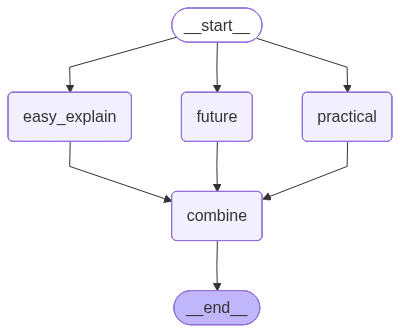

In [15]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [16]:
initial_message = {"question": "LangGraph란?"}
result = graph.invoke(initial_message)
print("final_answer:", result["final_answer"])

[병렬1 - easy_explain_node] 초등학생도 이해할 수 있는 설명[병렬3 - future_node] 기술 트렌드와 미래를 예측하는 전문가의 설명

[병렬2 - practical_node] 실 개발자의 실제 활용법 또는 예제 중심의 설명
easy_explain_node의 LLM 응답: 안녕! 우리 친구들, 혹시 '챗GPT' 같은 똑똑한 인공지능 로봇 알아? 🤖

보통은 우리가 "이거 해줘!" 하면 딱 한 가지를 해줘.
예를 들어, "재미있는 이야기 하나 만들어줘!" 하면 이야기를 만들어주지.

근데 만약 로봇한테 이렇게 시키고 싶으면 어떡할까?

1.  "먼저, 오늘 날씨가 어떤지 찾아봐."
2.  "그 다음에, 날씨가 좋으면 '공원에 가자!'고 말해줘."
3.  "만약 날씨가 안 좋으면 '집에서 영화 볼까?'라고 말해줘."
4.  "그리고 내가 '좋아!'라고 하면, 공원에 갈 준비물이나 영화 추천을 해줘."

이렇게 **여러 단계를 순서대로** 시키고, **중간에 상황에 따라 다른 선택**을 하게 만들고 싶을 때가 있겠지?

이럴 때 쓰는 마법 같은 도구가 바로 **'랭그래프(LangGraph)'**야! ✨

쉽게 말해서, 랭그래프는...

1.  **'랭(Lang)'**: 똑똑한 인공지능 로봇(언어 모델)을 말해. (우리 친구들이 아는 챗GPT 같은 애들!)
2.  **'그래프(Graph)'**: 마치 우리가 놀이터에서 미끄럼틀 타고, 그네 타고, 시소 타는 것처럼, 여러 가지 길을 만들어서 로봇이 어떤 순서로 움직일지 알려주는 **'지도'** 같은 거야.

**더 쉽게 비유하자면,**

랭그래프는 똑똑한 로봇을 위한 **'나만의 모험 이야기 책'**을 만드는 것과 비슷해! 📖

*   이야기 책을 읽다가 "오른쪽 길로 갈까? 왼쪽 길로 갈까?" 하고 우리가 선택하잖아?
*   랭그래프는 로봇한테 "자, 이제 이 질문을 해봐. 만약 대답이 이거면 1번 길로 가고, 저거면 2번 길로 가!" 하고 알려주는 거야.
*   그래서 로봇이 한 번에 한 가

In [17]:
result

{'question': 'LangGraph란?',
 'final_answer': "LangGraph는 AI에게 복잡한 일을 시키기 위한 '계획표'나 '레시피' 같은 도구예요. 단순히 한 번 질문하고 답하는 것을 넘어, 여러 단계를 거쳐 문제를 해결하도록 돕죠. 마치 요리사가 여러 재료와 조리법을 순서대로 사용해서 맛있는 음식을 만들듯이, LangGraph는 AI가 다양한 정보와 도구를 단계별로 활용해서 더 똑똑하고 복잡한 작업을 수행하게 해줍니다.\n\n실제 개발 관점에서 보면, LangGraph는 LangChain을 기반으로 하는 강력한 라이브러리로, AI 모델(LLM)이 여러 단계를 거쳐 작업을 수행하도록 설계하는 데 특화되어 있습니다. **노드(Node)**를 통해 각 단계(LLM 호출, 도구 사용, 사용자 정의 로직 등)를 정의하고, **엣지(Edge)**로 이 단계들을 연결하여 데이터 흐름과 실행 순서를 제어합니다. 특히, **상태(State)**를 관리하며 이전 단계의 정보를 다음 단계로 넘겨주거나 업데이트할 수 있고, **순환(Cycle) 구조**를 지원하여 AI가 스스로 판단하고 반복적으로 작업을 수행하거나, 특정 조건에서 다시 처음으로 돌아가 재시도하는 등 복잡한 '에이전트(Agent)' 행동을 구현할 수 있게 합니다. 이는 복잡한 RAG(검색 증강 생성), 자율 에이전트, 다단계 의사결정 시스템, 인간 개입(Human-in-the-loop)이 필요한 워크플로우 등을 구축할 때 매우 유용합니다.\n\n이러한 LangGraph의 능력은 미래 AI의 모습을 크게 바꿀 잠재력을 가지고 있습니다. 단순히 질문에 답하는 것을 넘어, AI가 스스로 목표를 설정하고, 필요한 도구를 찾아 사용하며, 실패 시 전략을 수정하는 등 더욱 **자율적이고 지능적인 행동**을 가능하게 할 것입니다. 이는 복잡한 과학 연구, 창의적인 작업, 개인화된 학습 등 다양한 분야에서 AI가 인간의 **강력한 협력자**이자 **문제 해결사**로 진화하는 데 핵심적인 역할을 할 것입